# Solution - Exercice 6 : Analyse de Sentiments avec ML Classique

## Imports et données

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords

reviews = [
    "Excellent produit, très satisfait! Livraison rapide, je recommande!",
    "Pourquoi ce produit est-il si cher pour une si mauvaise qualité?",
    "Parfait! Exactement ce que j'attendais. Très bon rapport qualité-prix.",
    "Horrible expérience. Le produit est cassé à la réception.",
    "Magnifique! Dépassé mes attentes. Un incontournable.",
    "Décevant. Les photos du site ne correspondaient pas au produit réel.",
    "Super ! Très content de mon achat. Je rachèterai!",
    "Pire achat de ma vie. Service client inexistant.",
    "Bon produit pour le prix. Pas extraordinaire mais correct.",
    "Absolument terrible. Qualité déplorable et défaut de fabrication.",
    "Sympa ! Livré rapidement et bien emballé.",
    "Vraiment nul. Ça ne fonctionne pas du tout.",
    "Très bien! Produit conforme à la description.",
    "Complètement inutile, j'ai demandé le remboursement.",
    "Excellent service et produit de qualité!",
    "Déception totale. N'achetez pas ce produit.",
]

labels = np.array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0])

## Tâche 1 : Préparation des données

In [ ]:
french_stopwords = stopwords.words("french")
# Vectorisation TF-IDF
vectorizer = TfidfVectorizer(max_features=100, stop_words=french_stopwords)
X = vectorizer.fit_transform(reviews)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Dimensions: {X.shape}")
print(f"Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")
print(
    f"Classe distribution train: Positif={y_train.sum()}, Négatif={(1 - y_train).sum()}"
)
print(f"Classe distribution test: Positif={y_test.sum()}, Négatif={(1 - y_test).sum()}")

Dimensions: (16, 66)
Train: 12 samples, Test: 4 samples
Classe distribution train: Positif=6, Négatif=6
Classe distribution test: Positif=2, Négatif=2


## Tâche 2 : Logistic Regression

In [3]:
# Entraîner
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

# Prédire
y_pred_lr = lr.predict(X_test)

# Métriques
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr, zero_division=0):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_lr, zero_division=0):.4f}")

# Matrice de confusion
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(f"\nMatrice de confusion:\n{cm_lr}")

Accuracy:  0.7500
Precision: 0.6667
Recall:    1.0000
F1-score:  0.8000

Matrice de confusion:
[[1 1]
 [0 2]]


## Tâche 3 : Support Vector Machine

In [ ]:
# Tester différents kernels
kernels = ["linear", "rbf", "poly"]
svm_results = {}


for kernel in kernels:
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(X_train, y_train)
    y_pred_svm = svm.predict(X_test)

    acc = accuracy_score(y_test, y_pred_svm)
    f1 = f1_score(y_test, y_pred_svm, zero_division=0)
    svm_results[kernel] = {"acc": acc, "f1": f1, "model": svm}

    print(f"\nKernel: {kernel}")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1-score: {f1:.4f}")

# Meilleur kernel
best_kernel = max(svm_results, key=lambda k: svm_results[k]["acc"])
print(f"\nMeilleur kernel: {best_kernel}")


Kernel: linear
  Accuracy: 0.7500
  F1-score: 0.8000

Kernel: rbf
  Accuracy: 0.7500
  F1-score: 0.8000

Kernel: poly
  Accuracy: 0.7500
  F1-score: 0.8000

Meilleur kernel: linear


## Tâche 4 : Naive Bayes

In [5]:
# Entraîner
nb = MultinomialNB()
nb.fit(X_train, y_train)

# Prédire
y_pred_nb = nb.predict(X_test)

# Métriques
print(f"Accuracy:  {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_nb, zero_division=0):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_nb, zero_division=0):.4f}")

# Probabilités
y_proba_nb = nb.predict_proba(X_test[:3])
print(f"\nProbabilités (3 premiers tests):")
for i, proba in enumerate(y_proba_nb):
    print(f"  Sample {i}: Négatif={proba[0]:.3f}, Positif={proba[1]:.3f}")

Accuracy:  0.5000
Precision: 0.5000
Recall:    1.0000
F1-score:  0.6667

Probabilités (3 premiers tests):
  Sample 0: Négatif=0.424, Positif=0.576
  Sample 1: Négatif=0.405, Positif=0.595
  Sample 2: Négatif=0.498, Positif=0.502


## Tâche 5 : Feature Importance


Top 10 termes POSITIFS:
  excellent: 0.3834
  très: 0.2509
  service: 0.2414
  extraordinaire: 0.2111
  correct: 0.2111
  incontournable: 0.2013
  dépassé: 0.2013
  attentes: 0.2013
  magnifique: 0.2013
  content: 0.1912

Top 10 termes NÉGATIFS:
  si: -0.2899
  achetez: -0.2231
  totale: -0.2231
  déception: -0.2231
  horrible: -0.1947
  réception: -0.1947
  expérience: -0.1947
  cassé: -0.1947
  nul: -0.1788
  fonctionne: -0.1788


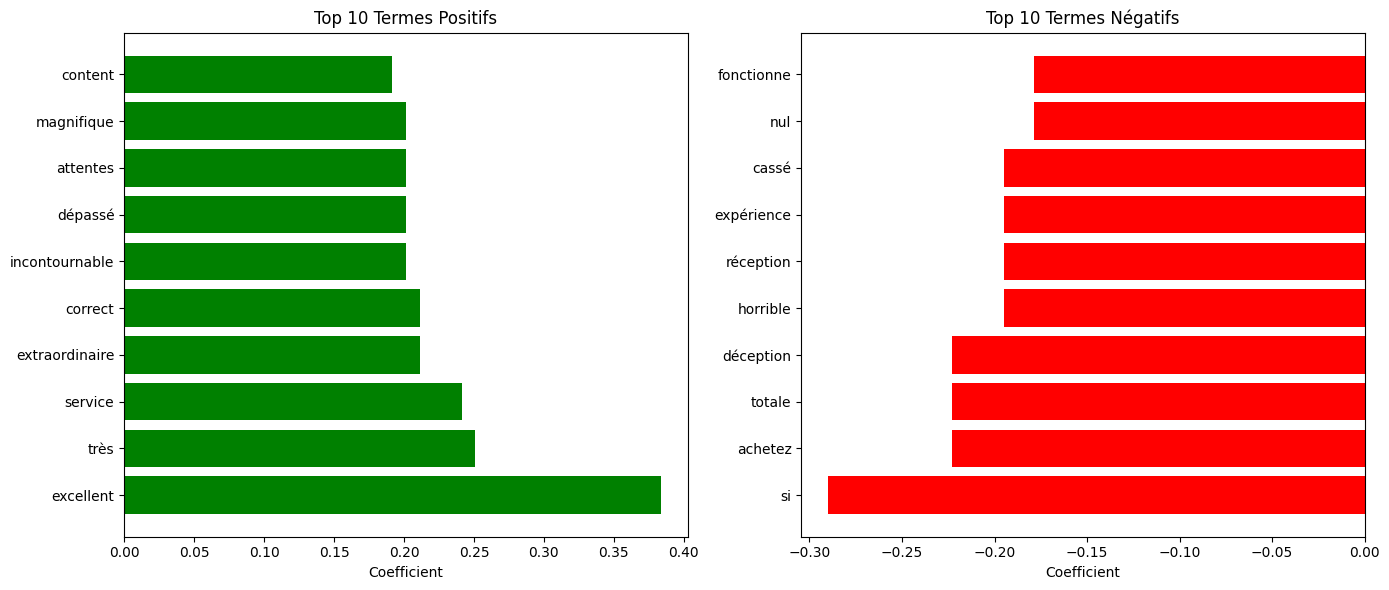

In [ ]:
# Coefficients Logistic Regression
feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = lr.coef_[0]

# Top 10 positifs et négatifs
top_positive_idx = coefficients.argsort()[-10:][::-1]
top_negative_idx = coefficients.argsort()[:10]

top_positive = feature_names[top_positive_idx]
top_negative = feature_names[top_negative_idx]

print("\nTop 10 termes POSITIFS:")
for term, coef in zip(top_positive, coefficients[top_positive_idx]):
    print(f"  {term}: {coef:.4f}")

print("\nTop 10 termes NÉGATIFS:")
for term, coef in zip(top_negative, coefficients[top_negative_idx]):
    print(f"  {term}: {coef:.4f}")

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.barh(top_positive, coefficients[top_positive_idx], color="green")
ax1.set_xlabel("Coefficient")
ax1.set_title("Top 10 Termes Positifs")

ax2.barh(top_negative, coefficients[top_negative_idx], color="red")
ax2.set_xlabel("Coefficient")
ax2.set_title("Top 10 Termes Négatifs")

plt.tight_layout()
plt.show()

## Tâche 6 : GridSearchCV

In [ ]:
# Tuning SVM
param_grid = {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]}
grid_search = GridSearchCV(SVC(), param_grid, cv=3, scoring="f1_weighted")
grid_search.fit(X_train, y_train)

print(f"Meilleurs paramètres: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

# Évaluation
y_pred_tuned = grid_search.predict(X_test)
acc_before = accuracy_score(y_test, svm_results["linear"]["model"].predict(X_test))
acc_after = accuracy_score(y_test, y_pred_tuned)

print(f"\nAccuracy avant tuning: {acc_before:.4f}")
print(f"Accuracy après tuning: {acc_after:.4f}")
print(f"Amélioration: {(acc_after - acc_before) * 100:.2f}%")

Meilleurs paramètres: {'C': 0.1, 'kernel': 'linear'}
Best CV score: 0.6000

Accuracy avant tuning: 0.7500
Accuracy après tuning: 0.7500
Amélioration: 0.00%


## Tâche 7 : Prédictions sur données nouvelles

In [ ]:
new_reviews = [
    "Excellent! Très satisfait de mon achat!",
    "Super, ça ne marche pas du tout.",
    "Bon produit, correct mais pas extraordinaire.",
    "Magnifique! Dépassé mes attentes!",
    "Décevant, qualité médiocre.",
]

# Vectoriser
X_new = vectorizer.transform(new_reviews)

# Prédire avec le meilleur modèle
y_pred_new = lr.predict(X_new)
y_proba_new = lr.predict_proba(X_new)

for i, (review, pred, proba) in enumerate(zip(new_reviews, y_pred_new, y_proba_new)):
    sentiment = "POSITIF" if pred == 1 else "NÉGATIF"
    confidence = proba[pred] * 100
    print(f"\n{i + 1}. Critique: {review}")
    print(f"   Prédiction: {sentiment} ({confidence:.1f}%)")


1. Critique: Excellent! Très satisfait de mon achat!
   Prédiction: POSITIF (61.4%)

2. Critique: Super, ça ne marche pas du tout.
   Prédiction: NÉGATIF (52.6%)

3. Critique: Bon produit, correct mais pas extraordinaire.
   Prédiction: POSITIF (57.7%)

4. Critique: Magnifique! Dépassé mes attentes!
   Prédiction: POSITIF (58.4%)

5. Critique: Décevant, qualité médiocre.
   Prédiction: NÉGATIF (54.2%)



# BONUS

In [ ]:
## Bonus 1 : Random Forest et XGBoost
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Random Forest

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_rf, zero_division=0):.4f}")

# Feature importance Random Forest
importances_rf = rf.feature_importances_
top_indices_rf = importances_rf.argsort()[-10:][::-1]

print("\nTop 10 features importantes (Random Forest):")
for idx in top_indices_rf:
    print(f"  {feature_names[idx]}: {importances_rf[idx]:.4f}")

# XGBoost

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss",
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb, zero_division=0):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_xgb, zero_division=0):.4f}")

# Feature importance XGBoost
importances_xgb = xgb_model.feature_importances_
top_indices_xgb = importances_xgb.argsort()[-10:][::-1]

print("\nTop 10 features importantes (XGBoost):")
for idx in top_indices_xgb:
    print(f"  {feature_names[idx]}: {importances_xgb[idx]:.4f}")

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
## Bonus 2 : Validation Croisée (K-Fold CV)
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Configuration K-Fold
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

# Modèles à tester
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "SVM (linear)": SVC(kernel="linear", random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=100,
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss",
    ),
}


cv_results = {}

for name, model in models.items():
    # Cross-validation sur l'ensemble complet
    scores = cross_val_score(model, X, labels, cv=skf, scoring="accuracy")

    cv_results[name] = {"mean": scores.mean(), "std": scores.std(), "scores": scores}

    print(f"\n{name}")
    print(f"  Scores par fold: {[f'{s:.4f}' for s in scores]}")
    print(f"  Moyenne: {scores.mean():.4f} (+/- {scores.std():.4f})")

# Meilleur modèle
best_model = max(cv_results, key=lambda k: cv_results[k]["mean"])
print(f"\n{'=' * 70}")
print(f"Meilleur modèle: {best_model}")
print(f"Score CV moyen: {cv_results[best_model]['mean']:.4f}")


Logistic Regression
  Scores par fold: ['0.7500', '0.6667', '0.6667', '0.3333', '0.3333']
  Moyenne: 0.5500 (+/- 0.1795)

SVM (linear)
  Scores par fold: ['0.7500', '1.0000', '0.6667', '0.6667', '0.0000']
  Moyenne: 0.6167 (+/- 0.3317)

Naive Bayes
  Scores par fold: ['0.5000', '1.0000', '1.0000', '0.3333', '0.3333']
  Moyenne: 0.6333 (+/- 0.3055)

Random Forest
  Scores par fold: ['0.7500', '0.3333', '0.6667', '0.0000', '0.3333']
  Moyenne: 0.4167 (+/- 0.2687)

XGBoost
  Scores par fold: ['0.5000', '0.0000', '0.0000', '0.0000', '0.0000']
  Moyenne: 0.1000 (+/- 0.2000)

Meilleur modèle: Naive Bayes
Score CV moyen: 0.6333


c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:21:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:21:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:21:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:21:29] WARNING: C:\actio

Logistic Regression: AUC = 1.0000
SVM (RBF): AUC = 0.0000
Naive Bayes: AUC = 1.0000
Random Forest: AUC = 0.5000
XGBoost: AUC = 0.2500


c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:21:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


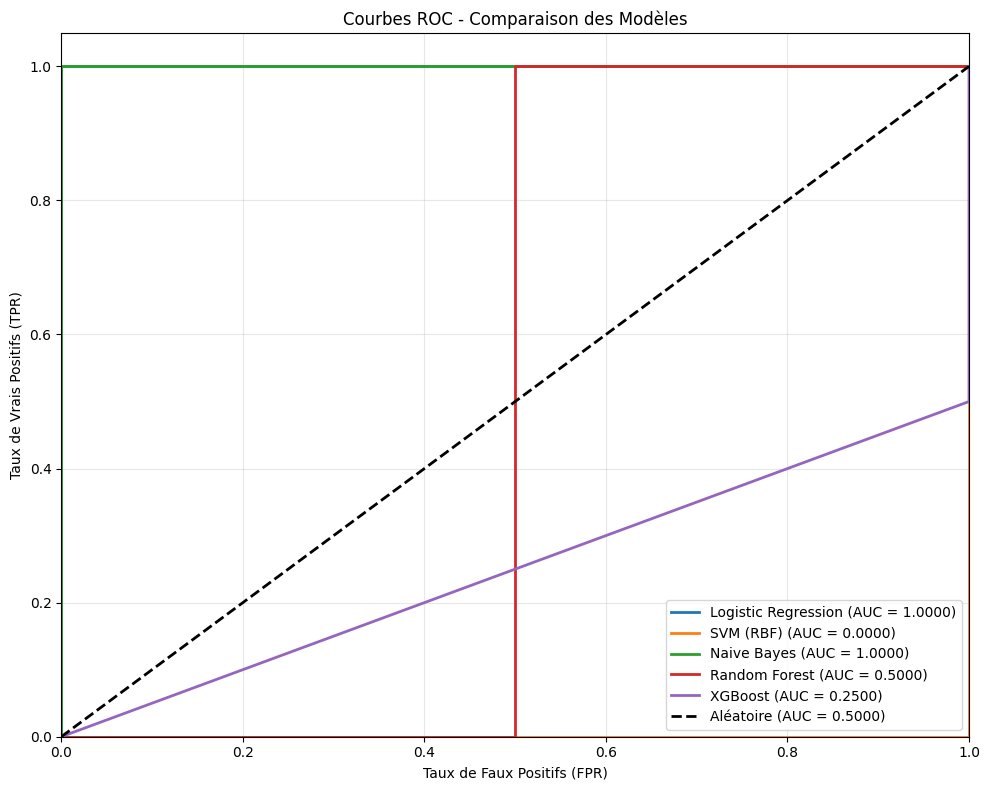

In [ ]:
## Bonus 3 : ROC Curve et AUC Score
from sklearn.metrics import roc_curve, auc

# Entraîner les modèles et obtenir les probabilités
models_for_roc = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=100,
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss",
    ),
}

plt.figure(figsize=(10, 8))

for name, model in models_for_roc.items():
    # Entraîner
    model.fit(X_train, y_train)

    # Obtenir les probabilités
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)

    # Calculer ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    print(f"{name}: AUC = {roc_auc:.4f}")

    # Tracer la courbe
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.4f})")

# Ligne de référence (modèle aléatoire)
plt.plot([0, 1], [0, 1], "k--", lw=2, label="Aléatoire (AUC = 0.5000)")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Taux de Faux Positifs (FPR)")
plt.ylabel("Taux de Vrais Positifs (TPR)")
plt.title("Courbes ROC - Comparaison des Modèles")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
## Bonus 4 : Word2Vec Embeddings
from gensim.models import Word2Vec
import re


# Prétraitement pour Word2Vec
def preprocess_for_w2v(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    return text.split()


# Tokeniser les critiques
tokenized_reviews = [preprocess_for_w2v(review) for review in reviews]

print(f"Nombre de critiques: {len(tokenized_reviews)}")
print(f"Exemple de tokens: {tokenized_reviews[0][:10]}")

# Entraîner Word2Vec
w2v_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=50,
    window=3,
    min_count=1,
    workers=1,
    seed=42,
)

print(f"\nVocabulaire Word2Vec: {len(w2v_model.wv)} mots")


# Fonction pour obtenir l'embedding moyen d'un document
def document_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)


# Créer les embeddings pour tous les documents
X_w2v = np.array([document_vector(tokens, w2v_model) for tokens in tokenized_reviews])

print(f"\nShape des embeddings: {X_w2v.shape}")

# Split train/test
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_w2v, labels, test_size=0.2, random_state=42, stratify=labels
)

Nombre de critiques: 16
Exemple de tokens: ['excellent', 'produit', 'très', 'satisfait', 'livraison', 'rapide', 'je', 'recommande']

Vocabulaire Word2Vec: 90 mots

Shape des embeddings: (16, 50)



Logistic Regression
  TF-IDF    : Accuracy=0.7500, F1=0.8000
  Word2Vec  : Accuracy=0.2500, F1=0.4000
  Différence: Accuracy=-0.5000, F1=-0.4000

SVM (linear)
  TF-IDF    : Accuracy=0.7500, F1=0.8000
  Word2Vec  : Accuracy=0.2500, F1=0.4000
  Différence: Accuracy=-0.5000, F1=-0.4000

Random Forest
  TF-IDF    : Accuracy=0.5000, F1=0.5000
  Word2Vec  : Accuracy=0.0000, F1=0.0000
  Différence: Accuracy=-0.5000, F1=-0.5000


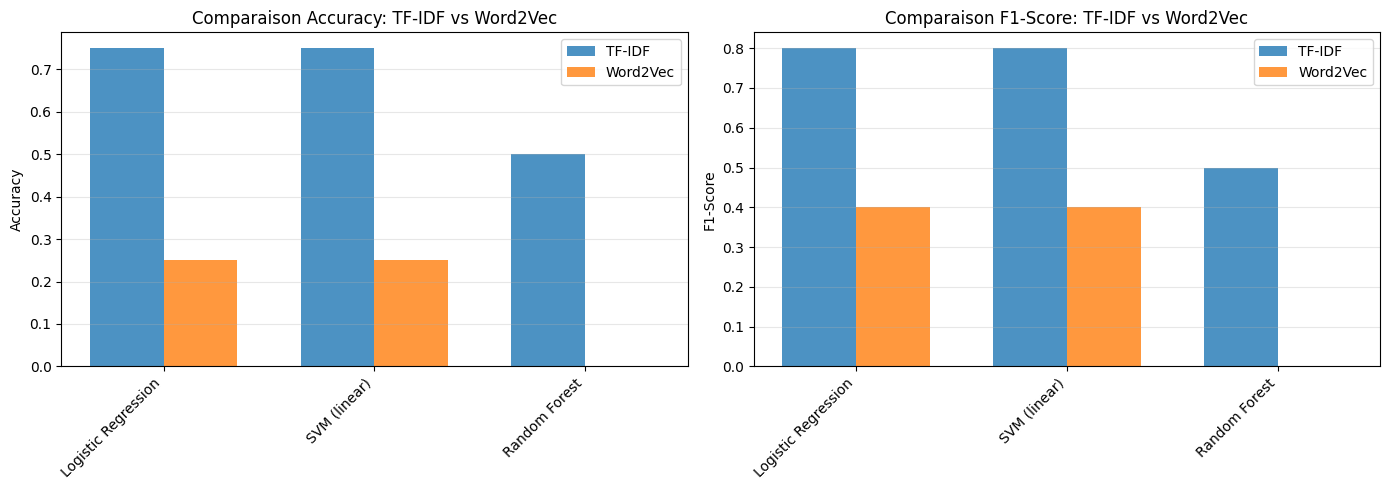

In [ ]:
# Comparaison TF-IDF vs Word2Vec
# Tester plusieurs modèles avec Word2Vec
test_models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "SVM (linear)": SVC(kernel="linear", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

comparison_results = []

for name, model in test_models.items():
    # Avec TF-IDF
    model_tfidf = model.__class__(**model.get_params())
    model_tfidf.fit(X_train, y_train)
    y_pred_tfidf = model_tfidf.predict(X_test)
    acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
    f1_tfidf = f1_score(y_test, y_pred_tfidf, zero_division=0)

    # Avec Word2Vec
    model_w2v = model.__class__(**model.get_params())
    model_w2v.fit(X_train_w2v, y_train_w2v)
    y_pred_w2v = model_w2v.predict(X_test_w2v)
    acc_w2v = accuracy_score(y_test_w2v, y_pred_w2v)
    f1_w2v = f1_score(y_test_w2v, y_pred_w2v, zero_division=0)

    comparison_results.append(
        {
            "model": name,
            "acc_tfidf": acc_tfidf,
            "acc_w2v": acc_w2v,
            "f1_tfidf": f1_tfidf,
            "f1_w2v": f1_w2v,
        }
    )

    print(f"\n{name}")
    print(f"  TF-IDF    : Accuracy={acc_tfidf:.4f}, F1={f1_tfidf:.4f}")
    print(f"  Word2Vec  : Accuracy={acc_w2v:.4f}, F1={f1_w2v:.4f}")
    print(
        f"  Différence: Accuracy={acc_w2v - acc_tfidf:+.4f}, F1={f1_w2v - f1_tfidf:+.4f}"
    )

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

model_names = [r["model"] for r in comparison_results]
x = np.arange(len(model_names))
width = 0.35

# Accuracy
acc_tfidf_vals = [r["acc_tfidf"] for r in comparison_results]
acc_w2v_vals = [r["acc_w2v"] for r in comparison_results]

ax1.bar(x - width / 2, acc_tfidf_vals, width, label="TF-IDF", alpha=0.8)
ax1.bar(x + width / 2, acc_w2v_vals, width, label="Word2Vec", alpha=0.8)
ax1.set_ylabel("Accuracy")
ax1.set_title("Comparaison Accuracy: TF-IDF vs Word2Vec")
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=45, ha="right")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

# F1-Score
f1_tfidf_vals = [r["f1_tfidf"] for r in comparison_results]
f1_w2v_vals = [r["f1_w2v"] for r in comparison_results]

ax2.bar(x - width / 2, f1_tfidf_vals, width, label="TF-IDF", alpha=0.8)
ax2.bar(x + width / 2, f1_w2v_vals, width, label="Word2Vec", alpha=0.8)
ax2.set_ylabel("F1-Score")
ax2.set_title("Comparaison F1-Score: TF-IDF vs Word2Vec")
ax2.set_xticks(x)
ax2.set_xticklabels(model_names, rotation=45, ha="right")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

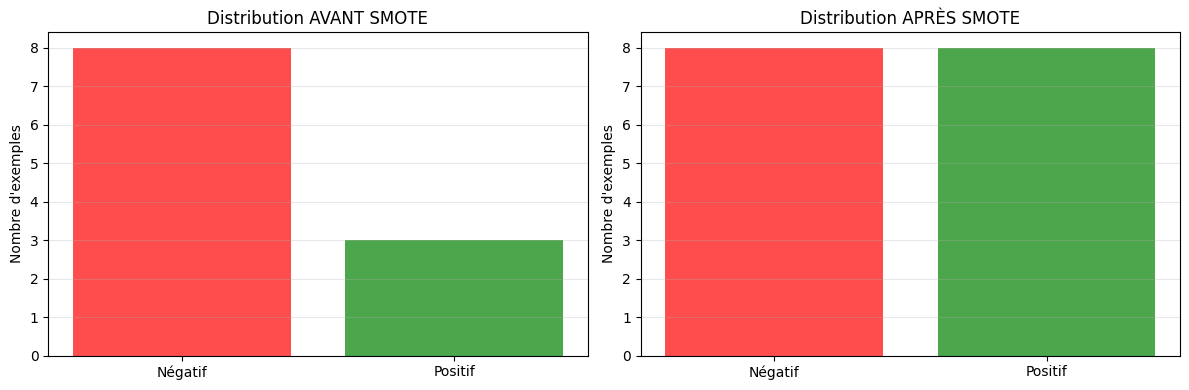

In [ ]:
## Bonus 5 : SMOTE pour gérer le déséquilibre de classes
# Installation : pip install imbalanced-learn

from imblearn.over_sampling import SMOTE
from collections import Counter

# Créer un dataset déséquilibré pour la démonstration
# (Dans notre cas, les données sont équilibrées, mais simulons un déséquilibre)
np.random.seed(42)

# Garder seulement 30% des exemples positifs pour simuler un déséquilibre
positive_indices = np.where(labels == 1)[0]
negative_indices = np.where(labels == 0)[0]

# Réduire les positifs (garder au moins 3 pour SMOTE avec k_neighbors=2)
selected_positive = np.random.choice(
    positive_indices, size=max(3, int(len(positive_indices) * 0.3)), replace=False
)
selected_indices = np.concatenate([negative_indices, selected_positive])

# Convertir la matrice sparse en dense
X_imbalanced = X[selected_indices].toarray()
y_imbalanced = labels[selected_indices]

# Appliquer SMOTE avec k_neighbors adapté
smote = SMOTE(random_state=42, k_neighbors=2)
X_resampled, y_resampled = smote.fit_resample(X_imbalanced, y_imbalanced)

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Avant SMOTE
ax1.bar(
    ["Négatif", "Positif"],
    [Counter(y_imbalanced)[0], Counter(y_imbalanced)[1]],
    color=["red", "green"],
    alpha=0.7,
)
ax1.set_ylabel("Nombre d'exemples")
ax1.set_title("Distribution AVANT SMOTE")
ax1.grid(axis="y", alpha=0.3)

# Après SMOTE
ax2.bar(
    ["Négatif", "Positif"],
    [Counter(y_resampled)[0], Counter(y_resampled)[1]],
    color=["red", "green"],
    alpha=0.7,
)
ax2.set_ylabel("Nombre d'exemples")
ax2.set_title("Distribution APRÈS SMOTE")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()